In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import random
import math

In [2]:
def sig(x):
    return 1/(1+np.exp(-x))# 这里只能用np，因为math只能传一个参数

这一版是直接梯度下降的，没有用minibatch

In [3]:
class LogisticRegression:
    def __init__(self, X, y):
        self.X = np.array(X)
        self.w = np.random.random(len(X[0]))
        self.y = np.array(y)
        self.m = len(y)
        self.loss_history = []
    
    def grad(self):
        return self.X.T @ (sig(self.X @ self.w) - self.y)
    
    def loss(self):
        
        y_hat = sig(self.X @ self.w)
        eps = 1e-15
        return -np.sum(self.y * np.log(y_hat + eps) + (1 - self.y) * np.log(1 - y_hat + eps))/self.m

    def fit(self, step, count):
        for i in range(count):
            self.w -= step * self.grad()
            self.loss_history.append(self.loss())
            if i % 100 == 0:
                print("loss = ", self.loss())

In [4]:
from sklearn.datasets import load_breast_cancer# 导入乳腺癌数据集

data = load_breast_cancer()
X = data.data # 特征矩阵，形状 (n_samples, n_features)
y = data.target # 标签向量，0/1

print(np.isnan(X).any()) # 检查是否有缺失值
print(np.isinf(X).any()) # 检查是否有无穷值

False
False


In [5]:
features = data.feature_names
print(features) # 这三十个特征，前十个是平均值，后十个是标准误差，最后十个是最大值
print(y) #y的分布较为随机，因此可以认为划分训练集和测试集时不需要分层抽样

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0

In [6]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

X_train = np.c_[X_train, np.ones(len(X_train))] # 添加偏置项
X_test = np.c_[X_test, np.ones(len(X_test))]

model = LogisticRegression(X_train, y_train)
model.fit(0.001, 10000)


loss =  3.341617728563677
loss =  0.06777373049280468
loss =  0.060311242257213224
loss =  0.056974115591033554
loss =  0.05493099168841521
loss =  0.05349217493550599
loss =  0.052392476190647644
loss =  0.051505238676569066
loss =  0.0507614058562166
loss =  0.05011982952155226
loss =  0.049554403672052515
loss =  0.04904776466946532
loss =  0.04858791075765602
loss =  0.04816626415087219
loss =  0.04777650656380325
loss =  0.04741385446284568
loss =  0.04707459488210778
loss =  0.04675578051317168
loss =  0.04645502468076798
loss =  0.046170360409091595
loss =  0.04590014149484554
loss =  0.04564297167064427
loss =  0.04539765291272986
loss =  0.04516314703225394
loss =  0.044938546641210116
loss =  0.04472305284154123
loss =  0.04451595781022242
loss =  0.04431663100241032
loss =  0.044124508066482146
loss =  0.04393908182000147
loss =  0.04375989481320036
loss =  0.04358653313160949
loss =  0.043418621178516616
loss =  0.043255817242009324
loss =  0.043097809697911396
loss =  0.04

In [7]:
test_loss = -np.sum(y_test * np.log(sig(X_test @ model.w)) + (1 - y_test) * np.log(1 - sig(X_test @ model.w)))/len(y_test)
print("test loss = ", test_loss)

test loss =  0.10418490587679488


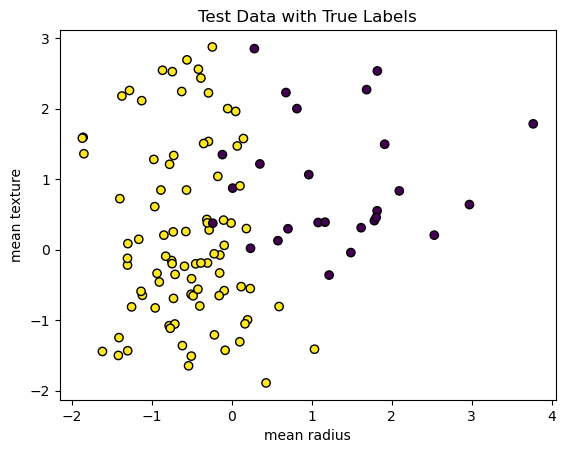

In [8]:
import matplotlib.pyplot as plt
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis', edgecolors='k')
plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title("Test Data with True Labels")
plt.show()

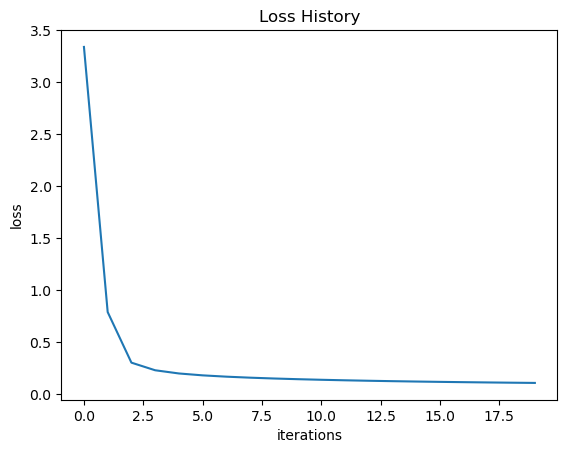

In [9]:
plt.plot(model.loss_history[:20]) # 只画前1000次迭代的损失值
plt.xlabel("iterations")
plt.ylabel("loss")
plt.title("Loss History")
plt.show()

In [10]:
from sklearn.linear_model import LogisticRegression as SkLogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, confusion_matrix
)

# ===== 1) 你的模型在测试集上的预测 =====
proba_my = sig(X_test @ model.w)                 # 概率
pred_my = (proba_my >= 0.5).astype(int)          # 分类

# ===== 2) sklearn模型（注意去掉你手动加的偏置列） =====
X_train_sk = X_train[:, :-1]
X_test_sk = X_test[:, :-1]

# 为了和你自写实现更接近，尽量关闭正则（不同版本sklearn参数名可能不同）
try:
    sk_model = SkLogisticRegression(
        penalty=None, solver="lbfgs", max_iter=5000, random_state=42
    )
except:
    sk_model = SkLogisticRegression(
        penalty="none", solver="lbfgs", max_iter=5000, random_state=42
    )

sk_model.fit(X_train_sk, y_train)

proba_sk = sk_model.predict_proba(X_test_sk)[:, 1]
pred_sk = (proba_sk >= 0.5).astype(int)

# ===== 3) 统一指标函数 =====
def get_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall":    recall_score(y_true, y_pred),
        "f1":        f1_score(y_true, y_pred),
        "auc":       roc_auc_score(y_true, y_prob),
        "log_loss":  log_loss(y_true, y_prob)
    }

m_my = get_metrics(y_test, pred_my, proba_my)
m_sk = get_metrics(y_test, pred_sk, proba_sk)

print("=== 我的 Logistic Regression ===")
for k, v in m_my.items():
    print(f"{k:10s}: {v:.6f}")
print("confusion_matrix:\n", confusion_matrix(y_test, pred_my))

print("\n=== sklearn LogisticRegression ===")
for k, v in m_sk.items():
    print(f"{k:10s}: {v:.6f}")
print("confusion_matrix:\n", confusion_matrix(y_test, pred_sk))

=== 我的 Logistic Regression ===
accuracy  : 0.956140
precision : 0.988235
recall    : 0.954545
f1        : 0.971098
auc       : 0.996503
log_loss  : 0.104185
confusion_matrix:
 [[25  1]
 [ 4 84]]

=== sklearn LogisticRegression ===
accuracy  : 0.938596
precision : 0.976471
recall    : 0.943182
f1        : 0.959538
auc       : 0.953671
log_loss  : 2.213207
confusion_matrix:
 [[24  2]
 [ 5 83]]


/opt/homebrew/Caskroom/miniforge/base/envs/aisoft/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
